In [1]:
# Cell 1: Import necessary libraries and check for GPU availability
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

device_name = tf.test.gpu_device_name()
if not device_name:
    print('Please activate GPU in Kaggle Settings > Accelerator')
else:
    print(f'Found GPU at: {device_name}')
print(f'TensorFlow version: {tf.__version__}')

2026-05-18 10:52:42.143126: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779101562.340111      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779101562.389639      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779101562.808624      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779101562.808659      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779101562.808662      23 computation_placer.cc:177] computation placer alr

Found GPU at: /device:GPU:0
TensorFlow version: 2.19.0


I0000 00:00:1779101587.929824      23 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779101587.936824      23 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [2]:
# Cell 2: Define directories and advanced hyperparameters
train_dir = '/kaggle/input/datasets/shamimulislamsunny/isic-2024-dataset/hair_removed/train'
test_dir  = '/kaggle/input/datasets/shamimulislamsunny/isic-2024-dataset/hair_removed/test'

IMG_SIZE  = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 20

# ASL Hyper-parameters
ASL_GAMMA_POS = 1.0
ASL_GAMMA_NEG = 4.0
ASL_CLIP      = 0.05

# AdamW Hyper-parameters
LR_PEAK       = 1e-4
LR_END        = 1e-6
WEIGHT_DECAY  = 1e-2
WARMUP_EPOCHS = 3

class_names = sorted(os.listdir(train_dir))
print("Classes:", class_names)

Classes: ['benign', 'malignant']


In [3]:
# Cell 3: Extract file paths and labels (Full test folder mapped for validation purpose)
def get_files_and_labels(directory):
    file_paths, labels = [], []
    for class_idx, class_name in enumerate(class_names):
        class_folder = os.path.join(directory, class_name)
        for img_name in os.listdir(class_folder):
            file_paths.append(os.path.join(class_folder, img_name))
            labels.append(class_idx)
    return np.array(file_paths), np.array(labels)

train_paths, train_labels = get_files_and_labels(train_dir)
test_paths,  test_labels  = get_files_and_labels(test_dir)

print(f"Train images : {len(train_paths)}")
print(f"Validation images (Full Test Folder) : {len(test_paths)}")

Train images : 322498
Validation images (Full Test Folder) : 80212


In [4]:
# Cell 4: Compute class weights via inverse frequency to counter heavy imbalance
total = len(train_labels)
neg   = int(np.sum(train_labels == 0))
pos   = int(np.sum(train_labels == 1))

class_weights = {
    0: (1 / neg) * (total / 2.0),
    1: (1 / pos) * (total / 2.0)
}
print(f"Class weights  ->  benign: {class_weights[0]:.4f},  malignant: {class_weights[1]:.4f}")
print(f"Imbalance ratio: {neg // pos}:1")

Class weights  ->  benign: 0.5031,  malignant: 82.0606
Imbalance ratio: 163:1


In [5]:
# Cell 5: Build tf.data pipeline with online augmentations
def preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.mobilenet_v3.preprocess_input(img)
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    return img, label

def create_ds(paths, labels, shuffle=False, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=2000, seed=42)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = create_ds(train_paths, train_labels, shuffle=True, augment_data=True)
val_ds   = create_ds(test_paths,  test_labels, shuffle=False) # Entire test folder assigned here

print("Datasets ready -- validation_data points to test folder")

I0000 00:00:1779101593.409304      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779101593.410765      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Datasets ready -- validation_data points to test folder


In [6]:
# Cell 6: Asymmetric Loss custom class for focal easy-negative suppression
class AsymmetricLoss(tf.keras.losses.Loss):
    def __init__(self, gamma_pos=1.0, gamma_neg=4.0, clip=0.05, eps=1e-8,
                 name='asymmetric_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.clip      = clip
        self.eps       = eps

    def call(self, y_true, y_pred):
        y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)

        y_pred_neg = tf.clip_by_value(y_pred - self.clip, 0.0, 1.0)

        loss_pos = y_true * (
            tf.pow(1.0 - y_pred, self.gamma_pos) *
            tf.math.log(tf.clip_by_value(y_pred, self.eps, 1.0))
        )
        loss_neg = (1.0 - y_true) * (
            tf.pow(y_pred_neg, self.gamma_neg) *
            tf.math.log(tf.clip_by_value(1.0 - y_pred_neg, self.eps, 1.0))
        )
        return tf.reduce_mean(-(loss_pos + loss_neg))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'gamma_pos': self.gamma_pos, 'gamma_neg': self.gamma_neg,
                    'clip': self.clip, 'eps': self.eps})
        return cfg

In [7]:
# Cell 7: Compile MobileNetV3 with WarmUp Cosine Decay Scheduler
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model

base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

total_steps  = len(train_ds) * EPOCHS
warmup_steps = len(train_ds) * WARMUP_EPOCHS

cosine_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR_PEAK,
    decay_steps=max(total_steps - warmup_steps, 1),
    alpha=LR_END / LR_PEAK
)

class WarmUpCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, warmup_steps, cosine_sched, peak_lr):
        super().__init__()
        self._warmup_steps  = tf.cast(warmup_steps, tf.float32)
        self._cosine_sched  = cosine_sched
        self._peak_lr       = peak_lr

    def __call__(self, step):
        step      = tf.cast(step, tf.float32)
        warmup_lr = self._peak_lr * (step / self._warmup_steps)
        cosine_lr = self._cosine_sched(step - self._warmup_steps)
        return tf.cond(step < self._warmup_steps, lambda: warmup_lr, lambda: cosine_lr)

    def get_config(self):
        return {}

lr_schedule = WarmUpCosineDecay(warmup_steps, cosine_schedule, LR_PEAK)

try:
    optimizer = tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=WEIGHT_DECAY, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
    print("Using tf.keras.optimizers.AdamW")
except AttributeError:
    optimizer = tf.keras.optimizers.experimental.AdamW(learning_rate=lr_schedule, weight_decay=WEIGHT_DECAY)
    print("Using tf.keras.optimizers.experimental.AdamW")

asl_loss = AsymmetricLoss(gamma_pos=ASL_GAMMA_POS, gamma_neg=ASL_GAMMA_NEG, clip=ASL_CLIP)

model.compile(
    optimizer=optimizer,
    loss=asl_loss,
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', curve='ROC'), tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Using tf.keras.optimizers.AdamW


In [8]:
# Cell 8: Train custom classification head with frozen backbone
print("=" * 55)
print(" Phase 1: Head training  |  backbone frozen")
print("=" * 55)

checkpoint_p1 = tf.keras.callbacks.ModelCheckpoint(
    'MobileNetV3_ASL_AdamW_phase1.h5', monitor='val_auc', save_best_only=True, mode='max', verbose=1
)
early_stop_p1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc', patience=5, mode='max', restore_best_weights=True, verbose=1
)

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,  # Monitoring val_ds directly
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[checkpoint_p1, early_stop_p1]
)

 Phase 1: Head training  |  backbone frozen
Epoch 1/20


I0000 00:00:1779101609.816500      68 service.cc:152] XLA service 0x7f11bc0112c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779101609.816543      68 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779101609.816547      68 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779101611.486417      68 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-18 10:53:39.380259: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 10:53:39.519224: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 10:53:39.853032: E external/local_xl

10078/10079 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5710 - auc: 0.0063 - loss: 0.0919 - precision: 6.9007e-05 - recall: 0.0032

2026-05-18 11:07:52.986713: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 11:07:53.132262: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 11:07:53.265415: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 11:07:53.556802: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 11:07:53.692992: E external/local_xla/xla/stream_

10079/10079 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5710 - auc: 0.0064 - loss: 0.0919 - precision: 7.0830e-05 - recall: 0.0032

...

10079/10079 ━━━━━━━━━━━━━━━━━━━━ 348s 34ms/step - accuracy: 0.8300 - auc: 0.0112 - loss: 0.0227 - precision: 4.0911e-04 - recall: 0.0086 - val_accuracy: 0.6379 - val_auc: 0.9538 - val_loss: 0.0724 - val_precision: 0.0026 - val_recall: 0.9747
Epoch 14/20
10077/10079 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7917 - auc: 0.0109 - loss: 0.0249 - precision: 2.9460e-04 - recall: 0.0085
Epoch 14: val_auc did not improve from 0.95377
10079/10079 ━━━━━━━━━━━━━━━━━━━━ 343s 34ms/step - accuracy: 0.7918 - auc: 0.0112 - loss: 0.0250 - precision: 3.1315e-04 - recall: 0.0088 - val_accuracy: 0.6919 - val_auc: 0.9535 - val_loss: 0.0558 - val_precision: 0.0031 - val_recall: 0.9747
Epoch 15/20
10077/10079 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7985 - auc: 0.0110 - loss: 0.0219 - precision: 2.6897e-04 - recall: 0.0081
Epoch 15: val_auc improved from 0.95377 to 0.95911, saving model to MobileNetV3_ASL_AdamW_phase1.h5


10079/10079 ━━━━━━━━━━━━━━━━━━━━ 337s 33ms/step - accuracy: 0.7985 - auc: 0.0112 - loss: 0.0219 - precision: 2.8638e-04 - recall: 0.0084 - val_accuracy: 0.6988 - val_auc: 0.9591 - val_loss: 0.0435 - val_precision: 0.0032 - val_recall: 0.9747
Epoch 16/20
10078/10079 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7908 - auc: 0.0111 - loss: 0.0199 - precision: 2.3843e-04 - recall: 0.0086
Epoch 16: val_auc improved from 0.95911 to 0.96073, saving model to MobileNetV3_ASL_AdamW_phase1.h5


10079/10079 ━━━━━━━━━━━━━━━━━━━━ 349s 35ms/step - accuracy: 0.7909 - auc: 0.0113 - loss: 0.0199 - precision: 2.4838e-04 - recall: 0.0088 - val_accuracy: 0.8123 - val_auc: 0.9607 - val_loss: 0.0221 - val_precision: 0.0050 - val_recall: 0.9494
Epoch 17/20
10077/10079 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8178 - auc: 0.0111 - loss: 0.0143 - precision: 2.2623e-04 - recall: 0.0086
Epoch 17: val_auc improved from 0.96073 to 0.96118, saving model to MobileNetV3_ASL_AdamW_phase1.h5


10079/10079 ━━━━━━━━━━━━━━━━━━━━ 346s 34ms/step - accuracy: 0.8179 - auc: 0.0113 - loss: 0.0143 - precision: 2.4060e-04 - recall: 0.0088 - val_accuracy: 0.9103 - val_auc: 0.9612 - val_loss: 0.0099 - val_precision: 0.0098 - val_recall: 0.8987
Epoch 18/20
10079/10079 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8766 - auc: 0.0116 - loss: 0.0083 - precision: 2.8781e-04 - recall: 0.0096
Epoch 18: val_auc improved from 0.96118 to 0.96176, saving model to MobileNetV3_ASL_AdamW_phase1.h5


10079/10079 ━━━━━━━━━━━━━━━━━━━━ 377s 37ms/step - accuracy: 0.8766 - auc: 0.0117 - loss: 0.0083 - precision: 2.9344e-04 - recall: 0.0096 - val_accuracy: 0.9607 - val_auc: 0.9618 - val_loss: 0.0048 - val_precision: 0.0206 - val_recall: 0.8354
Epoch 19/20
10077/10079 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9195 - auc: 0.0117 - loss: 0.0050 - precision: 3.6380e-04 - recall: 0.0100
Epoch 19: val_auc did not improve from 0.96176
10079/10079 ━━━━━━━━━━━━━━━━━━━━ 377s 37ms/step - accuracy: 0.9195 - auc: 0.0119 - loss: 0.0050 - precision: 3.8512e-04 - recall: 0.0103 - val_accuracy: 0.9745 - val_auc: 0.9598 - val_loss: 0.0035 - val_precision: 0.0283 - val_recall: 0.7468
Epoch 20/20
10077/10079 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9434 - auc: 0.0118 - loss: 0.0035 - precision: 4.4496e-04 - recall: 0.0103
Epoch 20: val_auc did not improve from 0.96176
10079/10079 ━━━━━━━━━━━━━━━━━━━━ 359s 35ms/step - accuracy: 0.9434 - auc: 0.0120 - loss: 0.0035 - precision: 4.7103e-04 - recall


          COMPREHENSIVE EVALUATION DIRECTLY ON VALIDATION SET
2507/2507 ━━━━━━━━━━━━━━━━━━━━ 63s 23ms/step


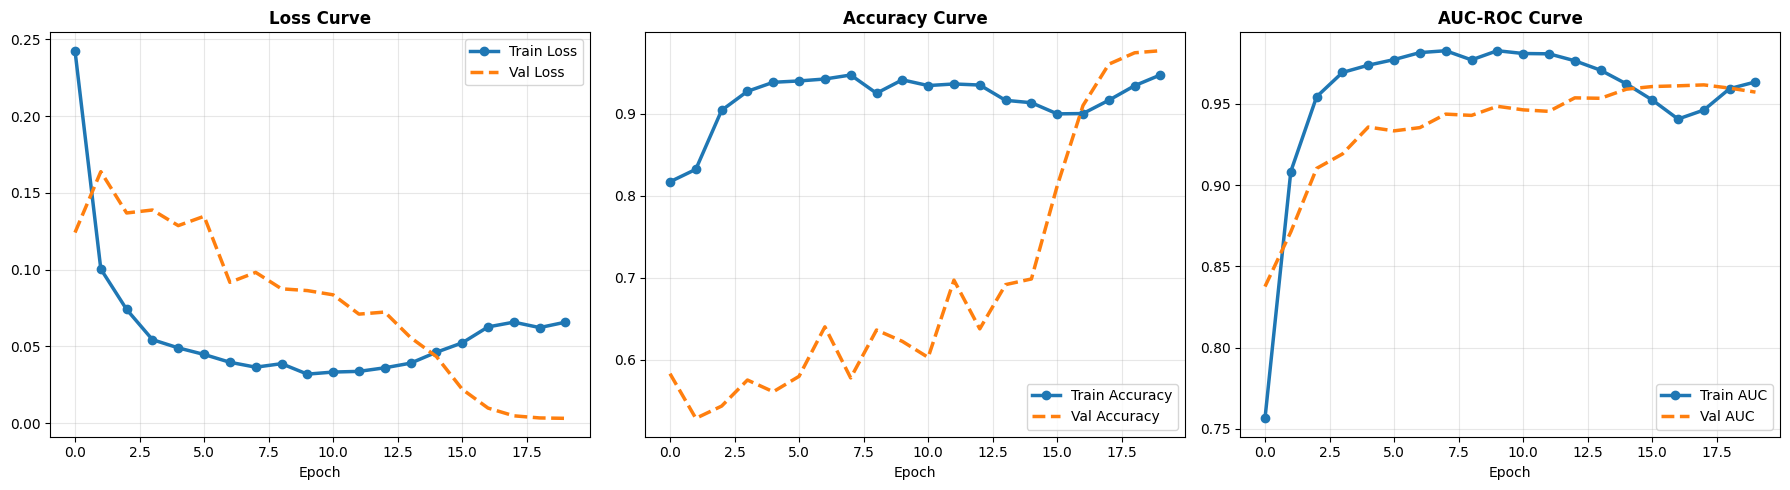

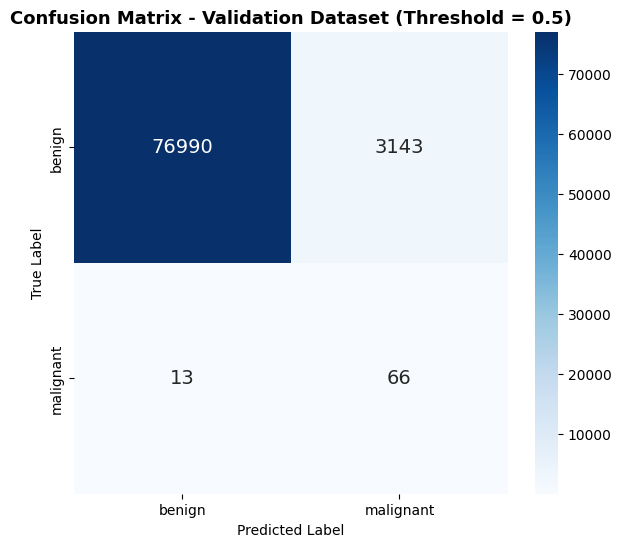

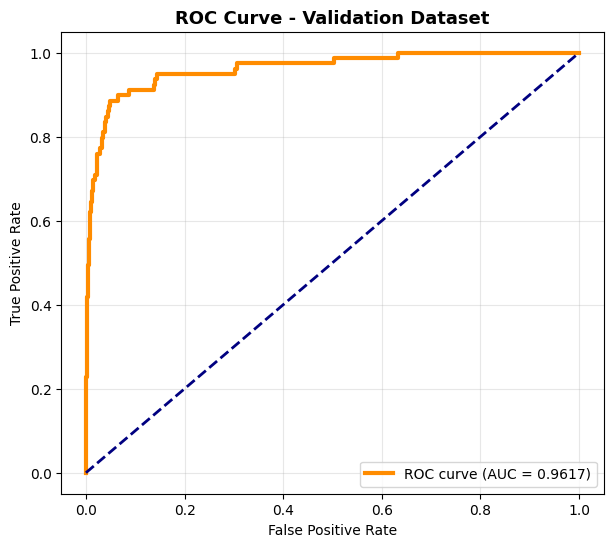


        FINAL VALIDATION PERFORMANCE METRICS
Accuracy:       0.9607
Precision:      0.0206
Recall:         0.8354
F1-Score:       0.0401
ROC-AUC:        0.9617

Detailed Classification Report:
              precision    recall  f1-score   support

      benign       1.00      0.96      0.98     80133
   malignant       0.02      0.84      0.04        79

    accuracy                           0.96     80212
   macro avg       0.51      0.90      0.51     80212
weighted avg       1.00      0.96      0.98     80212



In [9]:
# Cell 9: Generate metrics directly from the validation pipeline (val_ds)
print("\n" + "=" * 70)
print("          COMPREHENSIVE EVALUATION DIRECTLY ON VALIDATION SET")
print("=" * 70)

# Load best saved weights before evaluation
model.load_weights('MobileNetV3_ASL_AdamW_phase1.h5')

# Direct validation prediction probabilities
y_val_probs = model.predict(val_ds, verbose=1).flatten()
threshold = 0.5
y_val_pred  = (y_val_probs > threshold).astype(int)

# 100% Sequence locked validation labels
y_val_true  = test_labels  

# --- Training Curves ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history_p1.history['loss'], label='Train Loss', linewidth=2.5, marker='o')
axes[0].plot(history_p1.history['val_loss'], label='Val Loss', linewidth=2.5, linestyle='--')
axes[0].set_title('Loss Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_p1.history['accuracy'], label='Train Accuracy', linewidth=2.5, marker='o')
axes[1].plot(history_p1.history['val_accuracy'], label='Val Accuracy', linewidth=2.5, linestyle='--')
axes[1].set_title('Accuracy Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history_p1.history['auc'], label='Train AUC', linewidth=2.5, marker='o')
axes[2].plot(history_p1.history['val_auc'], label='Val AUC', linewidth=2.5, linestyle='--')
axes[2].set_title('AUC-ROC Curve', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Confusion Matrix ---
cm = confusion_matrix(y_val_true, y_val_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=class_names, yticklabels=class_names, annot_kws={'size': 14})
ax.set_title(f'Confusion Matrix - Validation Dataset (Threshold = {threshold})', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.show()

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_val_true, y_val_probs)
roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax.set_title('ROC Curve - Validation Dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.show()

# --- Numerical Summary ---
accuracy = accuracy_score(y_val_true, y_val_pred)
precision = precision_score(y_val_true, y_val_pred, zero_division=0)
recall = recall_score(y_val_true, y_val_pred)
f1 = f1_score(y_val_true, y_val_pred, zero_division=0)

print("\n" + "=" * 50)
print("        FINAL VALIDATION PERFORMANCE METRICS")
print("=" * 50)
print(f"Accuracy:       {accuracy:.4f}")
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"F1-Score:       {f1:.4f}")
print(f"ROC-AUC:        {roc_auc:.4f}")
print("=" * 50)

print("\nDetailed Classification Report:")
print(classification_report(y_val_true, y_val_pred, target_names=class_names, zero_division=0))